In [130]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [131]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
# Google Drive dataset path
DATA_DIR = "/content/drive/MyDrive/DL_Assigment/dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS = 15
LEARNING_RATE = 1e-4

SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# Reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [133]:

gpus = tf.config.list_physical_devices("GPU")

print("GPUs available:", len(gpus))

if gpus:
    for gpu in gpus:
        print(gpu)
else:
    print("WARNING: GPU not detected.")

GPUs available: 1
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [134]:
print("\nDataset path:")
print(DATA_DIR)

print("\nDataset folders:")

folders = sorted([
    folder for folder in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, folder))
])

print(folders)


Dataset path:
/content/drive/MyDrive/DL_Assigment/dataset

Dataset folders:
['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [135]:
class_names = sorted(folders)

NUM_CLASSES = len(class_names)

print("\n====================================")
print("CLASSES")
print("====================================")

for i, class_name in enumerate(class_names):
    print(i, "->", class_name)

print("\nNumber of classes:", NUM_CLASSES)


CLASSES
0 -> cataract
1 -> diabetic_retinopathy
2 -> glaucoma
3 -> normal

Number of classes: 4


In [136]:
image_paths = []
labels = []

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif"
)

for class_index, class_name in enumerate(class_names):

    class_directory = os.path.join(
        DATA_DIR,
        class_name
    )

    for root, _, files in os.walk(class_directory):

        for file_name in files:

            if file_name.lower().endswith(valid_extensions):

                file_path = os.path.join(
                    root,
                    file_name
                )

                image_paths.append(file_path)
                labels.append(class_index)


image_paths = np.array(image_paths)
labels = np.array(labels)

In [137]:
print("\n====================================")
print("TOTAL DATASET")
print("====================================")

print("Total images:", len(image_paths))

for class_index, class_name in enumerate(class_names):

    count = np.sum(labels == class_index)

    print(
        f"{class_name:25s}: {count}"
    )


TOTAL DATASET
Total images: 4217
cataract                 : 1038
diabetic_retinopathy     : 1098
glaucoma                 : 1007
normal                   : 1074


**Dataset Preparation.**  

In [138]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(

    image_paths,
    labels,

    test_size=0.30,

    random_state=SEED,

    stratify=labels
)


In [139]:
val_paths, test_paths, val_labels, test_labels = train_test_split(

    temp_paths,
    temp_labels,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_labels
)


In [140]:
print("\n====================================")
print("DATASET SPLIT")
print("====================================")

print("Training images  :", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images      :", len(test_paths))


DATASET SPLIT
Training images  : 2951
Validation images: 633
Test images      : 633


In [141]:
def print_distribution(name, labels_array):

    print(f"\n{name} distribution:")

    for class_index, class_name in enumerate(class_names):

        count = np.sum(
            labels_array == class_index
        )

        print(
            f"{class_name:25s}: {count}"
        )


In [142]:
print_distribution(
    "TRAIN",
    train_labels
)

print_distribution(
    "VALIDATION",
    val_labels
)

print_distribution(
    "TEST",
    test_labels
)


TRAIN distribution:
cataract                 : 726
diabetic_retinopathy     : 768
glaucoma                 : 705
normal                   : 752

VALIDATION distribution:
cataract                 : 156
diabetic_retinopathy     : 165
glaucoma                 : 151
normal                   : 161

TEST distribution:
cataract                 : 156
diabetic_retinopathy     : 165
glaucoma                 : 151
normal                   : 161


In [143]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    # Convert integer label to one-hot
    label = tf.one_hot(
        label,
        NUM_CLASSES
    )
    return image, label

In [144]:
def create_dataset(
    paths,
    labels,
    shuffle=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


In [145]:
train_ds = create_dataset(
    train_paths,
    train_labels,
    shuffle=True
)

val_ds = create_dataset(
    val_paths,
    val_labels,
    shuffle=False
)

test_ds = create_dataset(
    test_paths,
    test_labels,
    shuffle=False
)



In [146]:
print("\n====================================")
print("TEST LABEL VERIFICATION")
print("====================================")

print(
    "Test label distribution:",
    np.bincount(
        test_labels,
        minlength=NUM_CLASSES
    )
)


TEST LABEL VERIFICATION
Test label distribution: [156 165 151 161]


**Image preprocessing**

In [147]:
data_augmentation = keras.Sequential(

    [

        layers.RandomFlip(
            mode="horizontal"
        ),

        layers.RandomRotation(
            factor=0.15
        ),

        layers.RandomZoom(
            height_factor=0.12,
            width_factor=0.12
        ),

        layers.RandomContrast(
            factor=0.10
        ),

        layers.RandomBrightness(
            factor=0.10
        )

    ],

    name="data_augmentation"
)

In [148]:
class_weights = compute_class_weight(

    class_weight="balanced",

    classes=np.arange(NUM_CLASSES),

    y=train_labels
)


class_weight_dict = {
    i: float(weight)
    for i, weight in enumerate(class_weights)
}


print("\n====================================")
print("CLASS WEIGHTS")
print("====================================")

for i, class_name in enumerate(class_names):

    print(
        f"{class_name:25s}: "
        f"{class_weight_dict[i]:.4f}"
    )



CLASS WEIGHTS
cataract                 : 1.0162
diabetic_retinopathy     : 0.9606
glaucoma                 : 1.0465
normal                   : 0.9811


EfficientNet-B0
ImageNet pretrained weights

In [149]:
base_model = keras.applications.EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224, 224, 3)
)


# Fine tuning
base_model.trainable = True

In [150]:
inputs = layers.Input(

    shape=(224, 224, 3),

    name="input_image"
)


# Data augmentation
x = data_augmentation(
    inputs,
    training=True
)


# EfficientNet-B0
x = base_model(
    x,
    training=True
)


# Global Average Pooling
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)


# Batch normalization
x = layers.BatchNormalization(
    name="batch_normalization"
)(x)


# Dropout
x = layers.Dropout(
    0.40,
    name="dropout"
)(x)

# Final classification layer
outputs = layers.Dense(

    NUM_CLASSES,

    activation="softmax",

    name="predictions"

)(x)


# Create model
model = keras.Model(

    inputs,

    outputs,

    name="EfficientNetB0_Eye_Disease"

)



In [151]:
model.summary()

Model: "EfficientNetB0_Eye_Disease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 4,015,232 (15.32 MB)

 Non-trainable params: 44,583 (174.16 KB)

In [152]:
model.compile(

    optimizer=keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [153]:
callbacks = [

    keras.callbacks.ModelCheckpoint(

        "best_efficientnet_b0.keras",

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-7,

        verbose=1

    ),

     keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True,

        verbose=1

    )

]


In [154]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    class_weight=class_weight_dict,

    callbacks=callbacks

)


Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.5363 - loss: 1.3809
Epoch 1: val_accuracy improved from None to 0.56240, saving model to best_efficientnet_b0.keras

Epoch 1: finished saving model to best_efficientnet_b0.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 85s 519ms/step - accuracy: 0.6483 - loss: 1.0339 - val_accuracy: 0.5624 - val_loss: 1.0849 - learning_rate: 1.0000e-04
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.7753 - loss: 0.6892
Epoch 2: val_accuracy improved from 0.56240 to 0.76935, saving model to best_efficientnet_b0.keras

Epoch 2: finished saving model to best_efficientnet_b0.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 422ms/step - accuracy: 0.7919 - loss: 0.6226 - val_accuracy: 0.7694 - val_loss: 0.6333 - learning_rate: 1.0000e-04
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.8172 - loss: 0.5196
Epoch 3: val_accuracy improved from 0.76935 to 0.80253, saving model to best_efficientnet_b0.keras

Epoch 3: finished saving model 

In [155]:
print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)



CLASSIFICATION REPORT
                      precision    recall  f1-score   support

            cataract     0.8818    0.9327    0.9065       104
diabetic_retinopathy     0.8818    0.8818    0.8818       110
            glaucoma     0.8557    0.8218    0.8384       101
              normal     0.8000    0.7850    0.7925       107

            accuracy                         0.8555       422
           macro avg     0.8548    0.8553    0.8548       422
        weighted avg     0.8548    0.8555    0.8549       422



In [156]:
test_loss, test_accuracy = model.evaluate(

    test_ds,

    verbose=1

)


print("\n====================================")
print("FINAL TEST RESULTS")
print("====================================")

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - accuracy: 0.8705 - loss: 0.4049

FINAL TEST RESULTS
Test Loss     : 0.4049
Test Accuracy : 87.05%


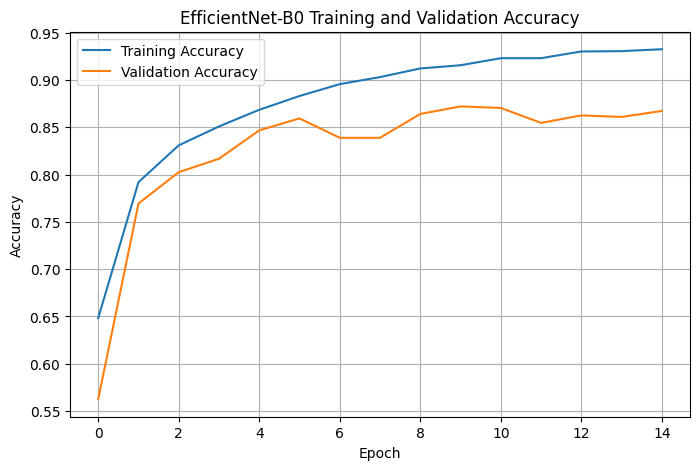

In [157]:
plt.figure(figsize=(8, 5))
plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title(
    "EfficientNet-B0 Training and Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

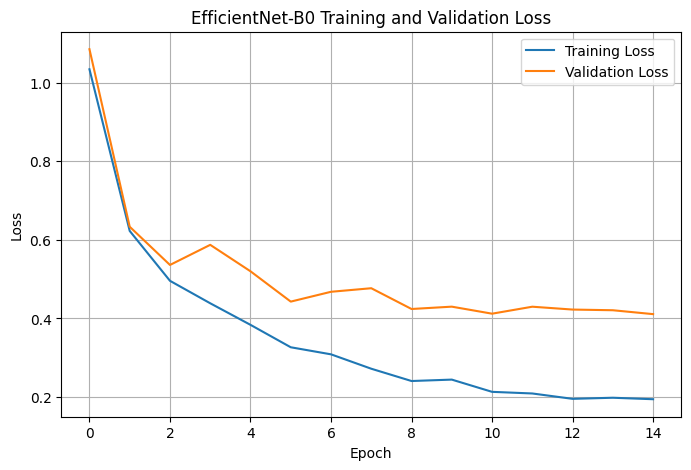

In [158]:
plt.figure(figsize=(8, 5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title(
    "EfficientNet-B0 Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()



In [159]:
y_true = []
y_pred = []


for images, labels_batch in test_ds:

    predictions = model.predict(

        images,

        verbose=0

    )


    predicted_classes = np.argmax(

        predictions,

        axis=1

    )

    true_classes = np.argmax(

        labels_batch.numpy(),

        axis=1

    )


    y_true.extend(
        true_classes
    )

    y_pred.extend(
        predicted_classes
    )


# Convert to NumPy
y_true = np.array(y_true)
y_pred = np.array(y_pred)



In [160]:
print("\n====================================")
print("CONFUSION MATRIX DATA CHECK")
print("====================================")

print(
    "Number of true labels:",
    len(y_true)
)

print(
    "Number of predictions:",
    len(y_pred)
)

print(
    "True label distribution:",
    np.bincount(
        y_true,
        minlength=NUM_CLASSES
    )
)

print(
    "Predicted label distribution:",
    np.bincount(
        y_pred,
        minlength=NUM_CLASSES
    )
)



CONFUSION MATRIX DATA CHECK
Number of true labels: 633
Number of predictions: 633
True label distribution: [156 165 151 161]
Predicted label distribution: [145 149 150 189]


In [161]:
print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")


print(

    classification_report(

        y_true,

        y_pred,

        labels=np.arange(NUM_CLASSES),

        target_names=class_names,

        digits=4,

        zero_division=0

    )

)


CLASSIFICATION REPORT
                      precision    recall  f1-score   support

            cataract     0.9586    0.8910    0.9236       156
diabetic_retinopathy     0.9530    0.8606    0.9045       165
            glaucoma     0.8333    0.8278    0.8306       151
              normal     0.7672    0.9006    0.8286       161

            accuracy                         0.8705       633
           macro avg     0.8780    0.8700    0.8718       633
        weighted avg     0.8786    0.8705    0.8722       633



In [162]:
cm = confusion_matrix(

    y_true,

    y_pred,

    labels=np.arange(NUM_CLASSES)

)


print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

print(cm)



CONFUSION MATRIX
[[139   0  11   6]
 [  3 142   2  18]
 [  2   4 125  20]
 [  1   3  12 145]]


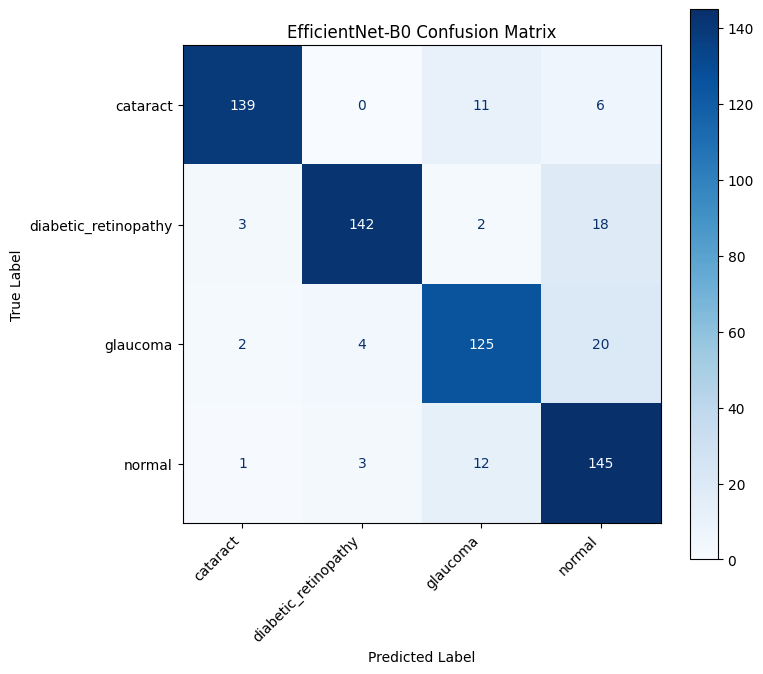

In [163]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)


disp.plot(

    ax=ax,

    cmap="Blues",

    values_format="d",

    colorbar=True

)

plt.title(
    "EfficientNet-B0 Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [168]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [167]:
y_true = []
y_prob = []

for images, labels_batch in test_ds:

    # Get probability for each class
    predictions = model.predict(
        images,
        verbose=0
    )

    # True class
    true_classes = np.argmax(
        labels_batch.numpy(),
        axis=1
    )

    y_true.extend(true_classes)
    y_prob.extend(predictions)


y_true = np.array(y_true)
y_prob = np.array(y_prob)

In [169]:

y_true_binary = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

In [170]:

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

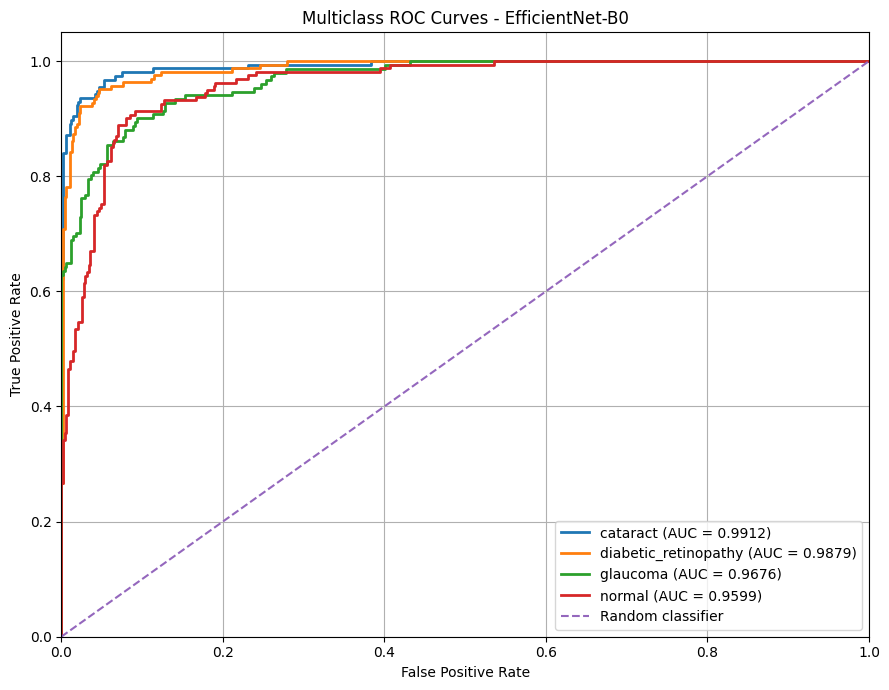

In [171]:
plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Multiclass ROC Curves - EfficientNet-B0"
)

plt.legend(
    loc="lower right"
)

plt.grid()

plt.xlim(
    [0.0, 1.0]
)

plt.ylim(
    [0.0, 1.05]
)

plt.tight_layout()

plt.show()



In [172]:

y_true_binary = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

In [173]:


import time


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)



y_true = []
y_pred = []
y_prob = []

inference_start = time.perf_counter()

for images, labels_batch in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    true_classes = np.argmax(
        labels_batch.numpy(),
        axis=1
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(true_classes)
    y_pred.extend(predicted_classes)
    y_prob.extend(predictions)

inference_end = time.perf_counter()


# Convert to NumPy
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)



print("====================================")
print("EVALUATION DATA CHECK")
print("====================================")

print("Number of test images :", len(y_true))
print("Number of predictions :", len(y_pred))
print("Probability shape     :", y_prob.shape)

print(
    "True label distribution:",
    np.bincount(
        y_true,
        minlength=NUM_CLASSES
    )
)

print(
    "Predicted distribution:",
    np.bincount(
        y_pred,
        minlength=NUM_CLASSES
    )
)




accuracy = accuracy_score(
    y_true,
    y_pred
)




precision_weighted = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)




recall_weighted = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)




f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)




f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)




roc_auc_macro = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="macro"
)




test_loss, test_accuracy_keras = model.evaluate(
    test_ds,
    verbose=0
)



best_val_accuracy = max(
    history.history["val_accuracy"]
)


best_epoch = (
    np.argmax(
        history.history["val_accuracy"]
    ) + 1
)




epochs_run = len(
    history.history["loss"]
)




total_parameters = model.count_params()

trainable_parameters = np.sum([
    np.prod(variable.shape)
    for variable in model.trainable_variables
])




training_time = None




total_inference_time = (
    inference_end - inference_start
)

inference_time_per_image = (
    total_inference_time / len(y_true)
)




print("\n")
print("============================================================")
print("                 MODEL EVALUATION RESULTS")
print("============================================================")

print(
    f"Accuracy                         : "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Precision (weighted)             : "
    f"{precision_weighted:.4f}"
)

print(
    f"Recall (weighted)                : "
    f"{recall_weighted:.4f}"
)

print(
    f"F1-score (weighted)              : "
    f"{f1_weighted:.4f}"
)

print(
    f"F1-score (macro)                 : "
    f"{f1_macro:.4f}"
)

print(
    f"ROC-AUC (macro, one-vs-rest)     : "
    f"{roc_auc_macro:.4f}"
)

print(
    f"Test loss                        : "
    f"{test_loss:.4f}"
)

print(
    f"Best validation accuracy        : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Best validation epoch           : "
    f"{best_epoch}"
)

print(
    f"Epochs run                      : "
    f"{epochs_run}"
)

print(
    f"Total parameters                : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters            : "
    f"{trainable_parameters:,}"
)

print(
    f"Inference time per image        : "
    f"{inference_time_per_image * 1000:.2f} ms"
)

print("============================================================")

EVALUATION DATA CHECK
Number of test images : 633
Number of predictions : 633
Probability shape     : (633, 4)
True label distribution: [156 165 151 161]
Predicted distribution: [145 149 150 189]


                 MODEL EVALUATION RESULTS
Accuracy                         : 87.05%
Precision (weighted)             : 0.8786
Recall (weighted)                : 0.8705
F1-score (weighted)              : 0.8722
F1-score (macro)                 : 0.8718
ROC-AUC (macro, one-vs-rest)     : 0.9767
Test loss                        : 0.4049
Best validation accuracy        : 87.20%
Best validation epoch           : 10
Epochs run                      : 15
Total parameters                : 4,059,815
Trainable parameters            : 4,015,232
Inference time per image        : 11.77 ms


In [180]:
import numpy as np
import pandas as pd

from sklearn.metrics import (

    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import label_binarize

# Class names
class_names = [
    "Cataract",
    "Diabetic Retinopathy",
    "Glaucoma",
    "Normal"
]

# Collect predictions from the CURRENT test dataset
y_true = []
y_prob = []

for images, labels_batch in test_ds:
    predictions = model.predict(images, verbose=0)

    true_classes = np.argmax(labels_batch.numpy(), axis=1)

    y_true.extend(true_classes)
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Convert probabilities to predicted class
y_pred = np.argmax(y_prob, axis=1)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

True labels: (633,)
Predictions: (633,)
Probabilities: (633, 4)


In [182]:
auc_scores = []

for i in range(len(class_names)):
    auc_value = roc_auc_score(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    auc_scores.append(auc_value)

In [183]:
results = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "AUC": auc_scores
})

# Round values
results["Precision"] = results["Precision"].round(3)
results["Recall"] = results["Recall"].round(3)
results["F1-Score"] = results["F1-Score"].round(3)
results["AUC"] = results["AUC"].round(3)

print(results.to_string(index=False))

               Class  Precision  Recall  F1-Score   AUC
            Cataract      0.959   0.891     0.924 0.991
Diabetic Retinopathy      0.953   0.861     0.904 0.988
            Glaucoma      0.833   0.828     0.831 0.968
              Normal      0.767   0.901     0.829 0.960
